## Linear VS Non-Linear Regression Demostration Using Advertising Data

In [2]:
# Step -1 Importing Important Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

In [3]:
# Step -2 Load the Dataset

data = pd.read_csv("advertising_nonlinear.csv")
data.head()

,TV,Radio,Newspaper,Sales,Sales_Nonlinear
0,230.1,37.8,69.2,22.1,5.35
1,44.5,39.3,45.1,10.4,7.20
2,17.2,45.9,69.3,12.0,7.77
3,151.5,41.3,58.5,16.5,9.82
4,180.8,10.8,58.4,17.9,5.66


In [4]:
# Step 3 - Select Features and target

X = data[['TV','Radio']]
y_linear = data['Sales_Nonlinear']

In [5]:
X.head()

,TV,Radio
0,230.1,37.8
1,44.5,39.3
2,17.2,45.9
3,151.5,41.3
4,180.8,10.8


In [6]:
y_linear.head()

0    5.35
1    7.20
2    7.77
3    9.82
4    5.66
Name: Sales_Nonlinear, dtype: float64

In [7]:
X.shape, y_linear.shape

((32, 2), (32,))

In [10]:
# Step 4: Split the data

In [8]:
X_train, X_test, y_train,y_test = train_test_split(X,y_linear, test_size = 0.2, random_state = 42)

In [9]:
X_train.shape, X_test.shape, y_train.shape,y_test.shape

((25, 2), (7, 2), (25,), (7,))

In [11]:
# Step 5 : Apply Linear Regression

In [12]:
lin_reg = LinearRegression()
lin_reg.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
# Preditc
y_pred_linear = lin_reg.predict(X_test)

In [14]:
# Evalueate the Linear Model

r2_lin = r2_score(y_test, y_pred_linear)
rmse_lin = np.sqrt(mean_squared_error(y_test,y_pred_linear))

print("Linear Regression R2:", round(r2_lin,3))
print("Linear Regression RMSE:", round(rmse_lin,3))

Linear Regression R2: 0.269
Linear Regression RMSE: 2.144


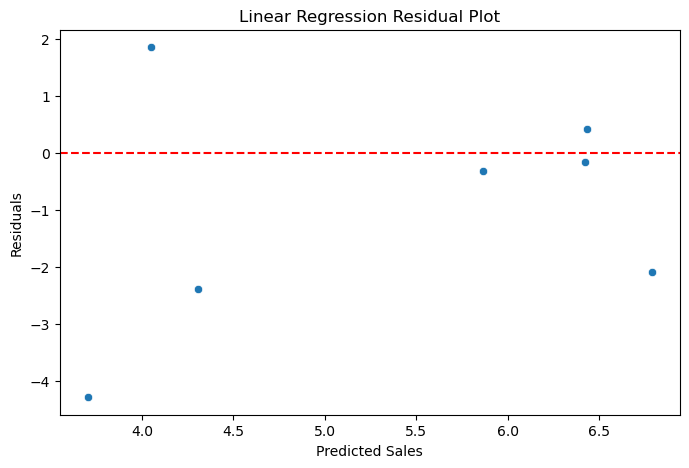

In [15]:
# Plot Residuals for Linear Regression
residual_lin = y_test - y_pred_linear
plt.figure(figsize = (8,5))
sns.scatterplot(x = y_pred_linear, y = residual_lin)
plt.axhline(0, color ='red', linestyle = '--')
plt.title("Linear Regression Residual Plot")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.show()

In [16]:
# Step 6: Apply Polynomial Regression(Degree 2)

from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree = 2, include_bias = False)

In [17]:
# Create polynomial features(degree = 2) to capture non-linear relationships

X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

In [18]:
poly_reg = LinearRegression()
poly_reg.fit(X_poly_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
# Predict
y_pred_poly = poly_reg.predict(X_poly_test)

In [20]:
# Evalueate the Polynomial Model

r2_poly = r2_score(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test,y_pred_poly))

print("Polynomial Regression R2:", round(r2_poly,3))
print("Polynomial Regression RMSE:", round(rmse_poly,3))

Polynomial Regression R2: 0.895
Polynomial Regression RMSE: 0.811


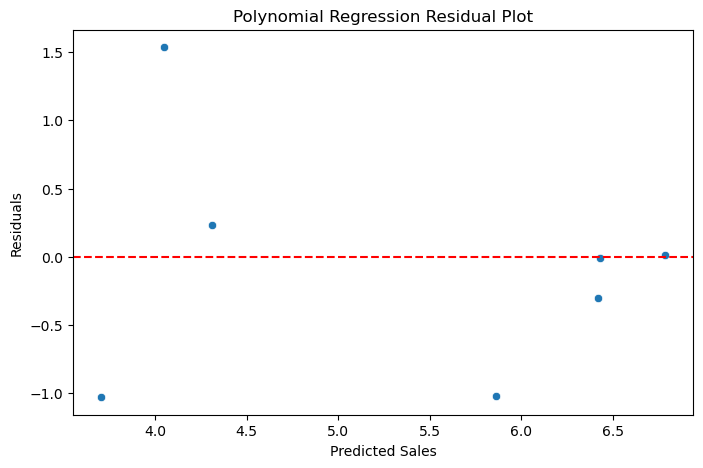

In [21]:
# Plot Residuals for Polynomial Regression
residual_poly = y_test - y_pred_poly
plt.figure(figsize = (8,5))
sns.scatterplot(x = y_pred_linear, y = residual_poly)
plt.axhline(0, color ='red', linestyle = '--')
plt.title("Polynomial Regression Residual Plot")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.show()

In [22]:
print("Linear Regression R2:", round(r2_lin,3))
print("Linear Regression RMSE:", round(rmse_lin,3))
print("-----------------------------------------\n")
print("Polynomial Regression R2:", round(r2_poly,3))
print("Polynomial Regression RMSE:", round(rmse_poly,3))

Linear Regression R2: 0.269
Linear Regression RMSE: 2.144
-----------------------------------------

Polynomial Regression R2: 0.895
Polynomial Regression RMSE: 0.811
